*DATA EXPLORATION*

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns
import os
import matplotlib.image as mpimg  
%matplotlib inline

In [56]:
airbnb_data = pd.read_csv('AB_NYC_2019.csv')
airbnb_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [57]:
airbnb_data.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [58]:
# Check the dataset shape (rows and columns
airbnb_data.shape


(48895, 16)

This dataset has around 49,000 observations in it with 16 columns and it is a mix between categorical and numeric values.

In [59]:
# Identify missing values for each column
airbnb_data.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

 We do already see some missing values, which will require cleaning and handling of NaN values. Later, we may need to continue with mapping certain values to ones and zeros for predictive analytics.

In [60]:
# Display summary statistics for numerical columns
airbnb_data.describe()  



,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


*DATA CLEANING*

In [61]:
# Handle missing values.
# name: replaced missing values with "Unknown".
airbnb_data['name'] = airbnb_data['name'].fillna('Unknown')
# host_name: filled missing values by mode per host_id, otherwise "Unknown".
airbnb_data['host_name'] = airbnb_data.groupby('host_id')['host_name'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
# last_review: filled missing values with "no_review".
airbnb_data['last_review'] = airbnb_data['last_review'].fillna('no_review')
# reviews_per_month: filled missing values with 0.
airbnb_data['reviews_per_month'] = airbnb_data['reviews_per_month'].fillna(0)



In [62]:
airbnb_data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [63]:
# Verify that numerical columns contain valid values.price <= 0: set as NaN and filled with median grouped by (neighbourhood, room_type).
airbnb_data['price'] = airbnb_data['price'].apply(lambda x: np.nan if x <= 0 else x)
airbnb_data['price'] = airbnb_data.groupby(['neighbourhood', 'room_type'])['price'].transform(lambda x: x.fillna(x.median()))


In [64]:
airbnb_data[airbnb_data['minimum_nights']<=0]
airbnb_data[airbnb_data['calculated_host_listings_count']<=0]
airbnb_data[airbnb_data['availability_365']<0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [65]:
# Remove duplicate rows.

print(f'Duplicates: {airbnb_data.duplicated().sum()}')

Duplicates: 0


In [66]:
# Convert data types for categorical columns to optimize memory usage.
airbnb_data['neighbourhood_group'] = airbnb_data['neighbourhood_group'].astype('category')
airbnb_data['neighbourhood']       = airbnb_data['neighbourhood'].astype('category')
airbnb_data['room_type']           = airbnb_data['room_type'].astype('category')

In [67]:
airbnb_data.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              48895 non-null  int64   
 1   name                            48895 non-null  object  
 2   host_id                         48895 non-null  int64   
 3   host_name                       48895 non-null  object  
 4   neighbourhood_group             48895 non-null  category
 5   neighbourhood                   48895 non-null  category
 6   latitude                        48895 non-null  float64 
 7   longitude                       48895 non-null  float64 
 8   room_type                       48895 non-null  category
 9   price                           48895 non-null  float64 
 10  minimum_nights                  48895 non-null  int64   
 11  number_of_reviews               48895 non-null  int64   
 12  last_review       

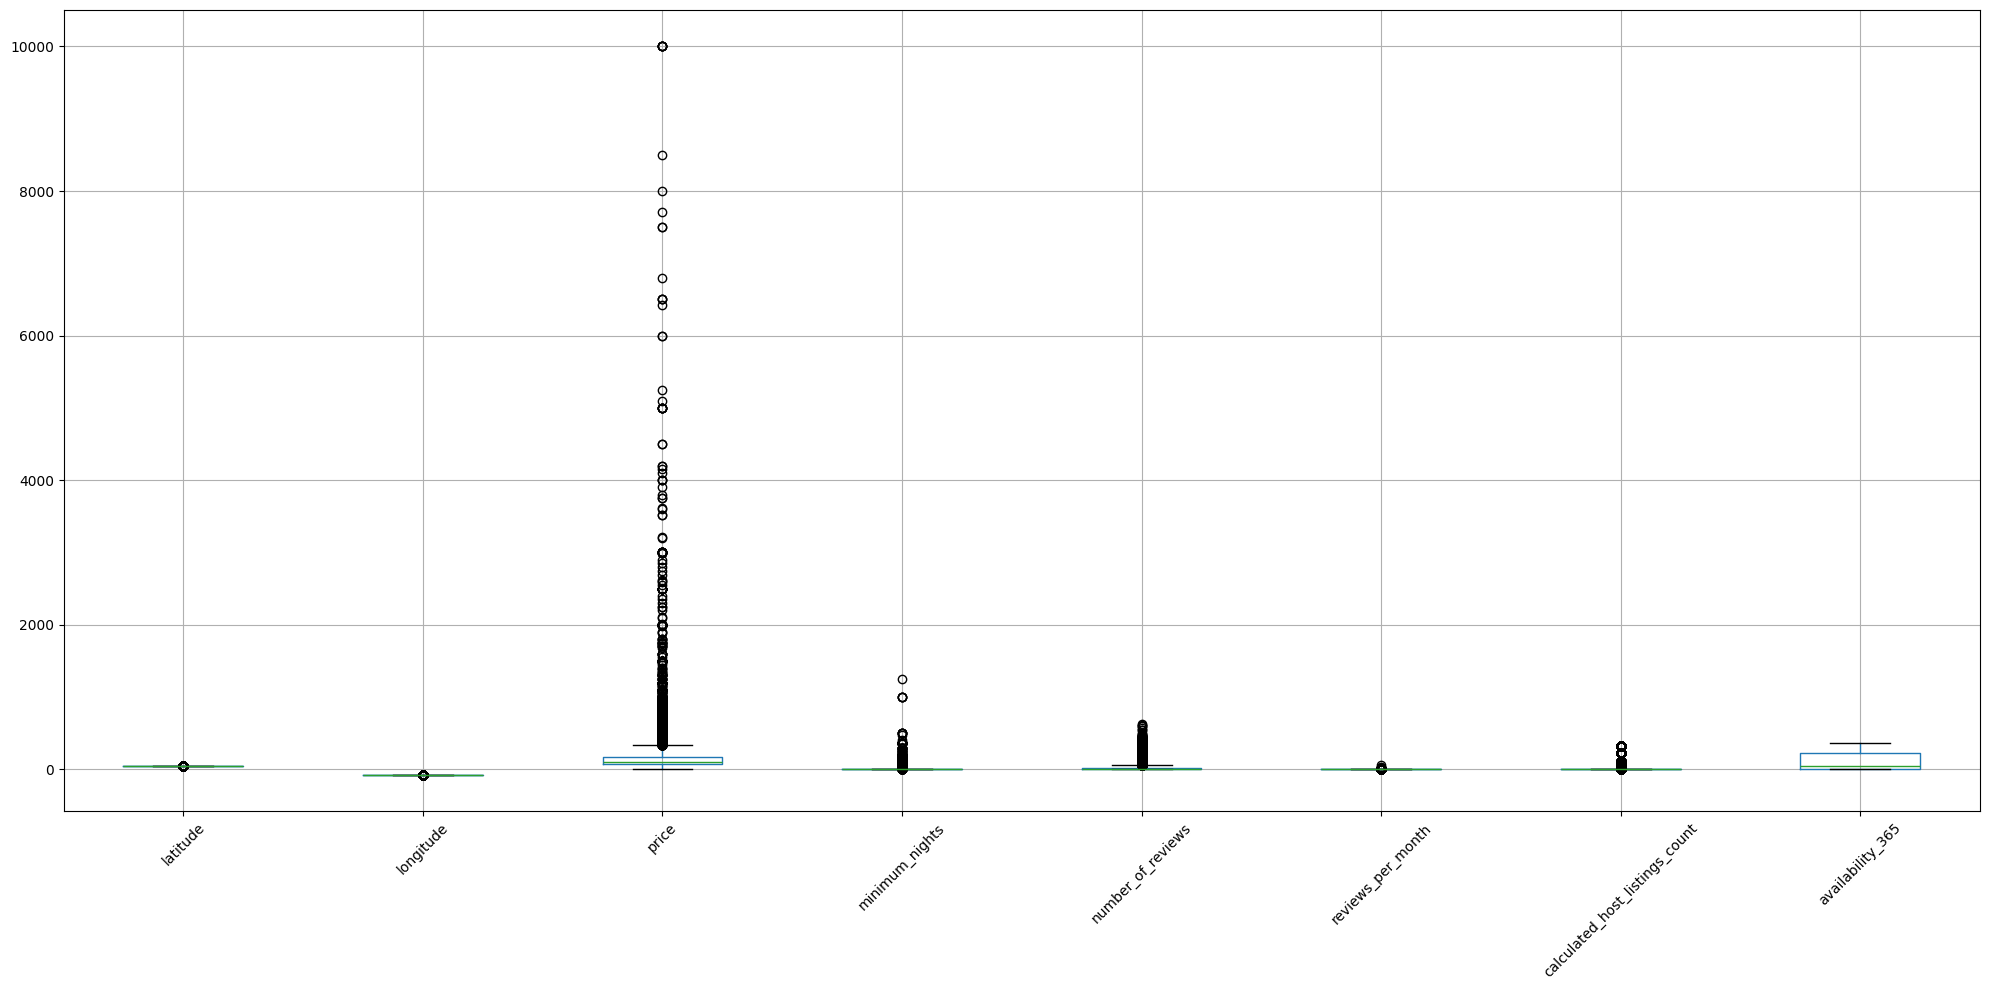

In [68]:
# Outlier detection
airbnb_data_numeric_cols=airbnb_data[['latitude','longitude','price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']]
airbnb_data_numeric_cols.boxplot(figsize=(20, 10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The columns 'id' and 'host_id' are just similar to index and range can be broad, so dropping these column will be better for box plot of numerical coumns because these 2 columns doesnt provide any insight.
column 'last_review' is is date format, so not including in numerical_cols
The box plot shows that the columns 'price','minimum_nights','number_of_reviews','calculated_host_listings_count' has outliers in them.

In [69]:
# Step 1: Calculate Q1, Q3, and IQR for 'price'
Q1 = airbnb_data['price'].quantile(0.25)
Q3 = airbnb_data['price'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 69.0
Q3: 175.0
IQR: 106.0


In [70]:
# Step 2: Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -90.0
Upper Limit: 334.0


In [71]:
# Step 3: Remove outliers
airbnb_data = airbnb_data[(airbnb_data['price'] >= lower_limit) & (airbnb_data['price'] <= upper_limit)]

print("After removing outliers, remaining rows:", airbnb_data.shape)

After removing outliers, remaining rows: (45923, 16)


In [72]:
# --- Export ---
airbnb_data.to_csv('AB_NYC_2019_cleaned.csv', index=False)
print('Saved → AB_NYC_2019_cleaned.csv')

Saved → AB_NYC_2019_cleaned.csv


*Data Analysis*

In [96]:
avg_price_neighbourhood = (
    airbnb_data.groupby("neighbourhood_group")["price"]
    .mean()
    .reset_index(name="avg_price")
    .sort_values(by="avg_price", ascending=False)
)

print(avg_price_neighbourhood)
print('---------------------------------------------------')

avg_price_room_type = (
    airbnb_data.groupby("room_type")["price"]
    .mean()
    .reset_index(name="avg_price")
    .sort_values(by="avg_price", ascending=False)
)

print(avg_price_room_type)
print('---------------------------------------------------')

median_price_neighbourhood = (
    airbnb_data.groupby("neighbourhood_group")["price"]
    .median()
    .reset_index(name="median_price")
    .sort_values(by="median_price", ascending=False)
)

print(median_price_neighbourhood)
print('---------------------------------------------------')

min_price = airbnb_data["price"].min()
max_price = airbnb_data["price"].max()

print("Minimum price:", min_price)
print("Maximum price:", max_price)

price_range_room_type = (
    airbnb_data.groupby("room_type")["price"]
    .agg(min_price="min", max_price="max")
    .reset_index()
)

print(price_range_room_type)


  neighbourhood_group   avg_price
2           Manhattan  145.963088
1            Brooklyn  105.731290
4       Staten Island   89.235616
3              Queens   88.904437
0               Bronx   77.433178
---------------------------------------------------
         room_type   avg_price
0  Entire home/apt  162.543552
1     Private room   79.038621
2      Shared room   59.355009
---------------------------------------------------
  neighbourhood_group  median_price
2           Manhattan         135.0
1            Brooklyn          90.0
4       Staten Island          75.0
3              Queens          74.0
0               Bronx          65.0
---------------------------------------------------
Minimum price: 10.0
Maximum price: 334.0
         room_type  min_price  max_price
0  Entire home/apt       10.0      334.0
1     Private room       10.0      333.0
2      Shared room       10.0      320.0


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\2293912458.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood_group")["price"]
C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\2293912458.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")["price"]
C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\2293912458.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

In [ ]:
top_hosts_listings = (
    airbnb_data.groupby(["host_id", "host_name"])
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
    .head(10)
)

print(top_hosts_listings )

print('---------------------------------------------------')


avg_price_per_host = (
    airbnb_data.groupby(["host_id", "host_name"])["price"]
    .mean()
    .reset_index(name="avg_price")
)

print(avg_price_per_host.head())

print('---------------------------------------------------')


top_hosts_avg_price = (
    airbnb_data.groupby(["host_id", "host_name"])["price"]
    .mean()
    .reset_index(name="avg_price")
    .sort_values(by="avg_price", ascending=False)
    .head(10)
)

print(top_hosts_avg_price)


         host_id          host_name  listing_count
32899  219517861       Sonder (NYC)            272
27974  107434423         Blueground            180
29565  137358866             Kazuya            103
18585   30283594               Kara             95
12126   12243051             Sonder             95
24407   61391963  Corporate Housing             91
13681   16098958     Jeremy & Laura             90
16229   22541573                Ken             87
9253     7503643               Vida             52
2904     1475015               Mike             52
---------------------------------------------------
   host_id host_name   avg_price
0     2438     Tasos   95.000000
1     2571     Teedo  182.000000
2     2787      John  100.666667
3     2845  Jennifer  162.000000
4     2868  Letha M.   60.000000
---------------------------------------------------
         host_id         host_name  avg_price
1147      412783              Nick      334.0
7085     4876826              Alex      333.0

C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\4099632251.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")["availability_365"]


         room_type  avg_availability
0  Entire home/apt        106.119400
1     Private room        109.978542
2      Shared room        163.053603


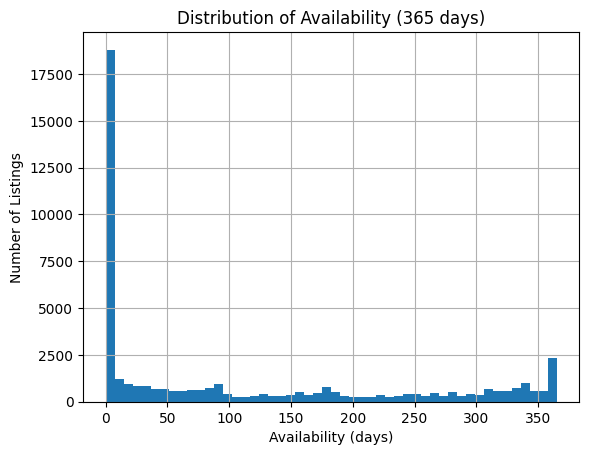

Very low availability listings: 21788
High availability listings: 7307


In [90]:
avg_availability_room = (
    airbnb_data.groupby("room_type")["availability_365"]
    .mean()
    .reset_index(name="avg_availability")
)

print(avg_availability_room)



plt.figure()
airbnb_data["availability_365"].hist(bins=50)

plt.title("Distribution of Availability (365 days)")
plt.xlabel("Availability (days)")
plt.ylabel("Number of Listings")

plt.show()


low_availability = airbnb_data[airbnb_data["availability_365"] < 30]
high_availability = airbnb_data[airbnb_data["availability_365"] > 300]

print("Very low availability listings:", len(low_availability))
print("High availability listings:", len(high_availability))

In [94]:
listings_by_neighbourhood_group = (
    airbnb_data.groupby("neighbourhood_group")
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(listings_by_neighbourhood_group)
print('---------------------------------------------------')


listings_by_room_type = (
    airbnb_data.groupby("room_type")
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(listings_by_room_type)

print('---------------------------------------------------')


listings_per_neighbourhood = (
    airbnb_data.groupby("neighbourhood")
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(listings_per_neighbourhood.head(10)) 


  neighbourhood_group  listing_count
2           Manhattan          19506
1            Brooklyn          19415
3              Queens           5567
0               Bronx           1070
4       Staten Island            365
---------------------------------------------------
         room_type  listing_count
0  Entire home/apt          22789
1     Private room          21996
2      Shared room           1138
---------------------------------------------------
          neighbourhood  listing_count
214        Williamsburg           3732
13   Bedford-Stuyvesant           3638
94               Harlem           2585
28             Bushwick           2438
202     Upper West Side           1788
95       Hell's Kitchen           1731
64         East Village           1714
201     Upper East Side           1670
51        Crown Heights           1519
127             Midtown           1144


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\1947769954.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood_group")
C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\1947769954.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")
C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\1947769954.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_

C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\3662433318.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")["price"]
C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\3662433318.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood_group")["price"]


         room_type   avg_price
0  Entire home/apt  162.543552
1     Private room   79.038621
2      Shared room   59.355009
---------------------------------------------------
  neighbourhood_group   avg_price
0               Bronx   77.433178
1            Brooklyn  105.731290
2           Manhattan  145.963088
3              Queens   88.904437
4       Staten Island   89.235616


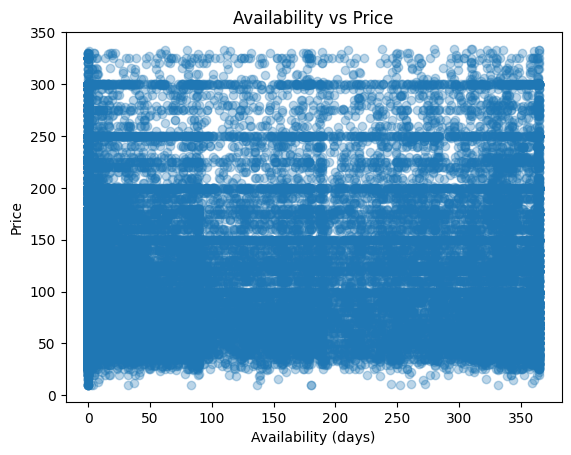

Correlation (availability vs price): 0.06657348828314388


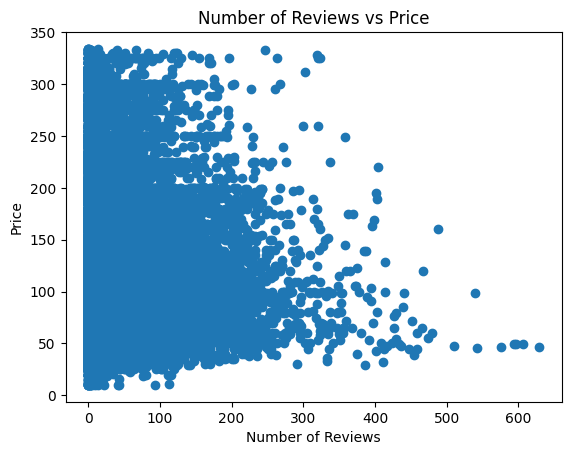

Correlation (reviews vs price): -0.02768039934976301


In [99]:
price_by_room = (
    airbnb_data.groupby("room_type")["price"]
    .mean()
    .reset_index(name="avg_price")
)

print(price_by_room)

print('---------------------------------------------------')

price_by_neighbourhood = (
    airbnb_data.groupby("neighbourhood_group")["price"]
    .mean()
    .reset_index(name="avg_price")
)

print(price_by_neighbourhood)

plt.figure()
plt.scatter(airbnb_data["availability_365"], airbnb_data["price"], alpha=0.3)
plt.title("Availability vs Price")
plt.xlabel("Availability (days)")
plt.ylabel("Price")

plt.show()

corr_availability_price = airbnb_data["availability_365"].corr(airbnb_data["price"])
print("Correlation (availability vs price):", corr_availability_price)


plt.figure()
plt.scatter(airbnb_data["number_of_reviews"], airbnb_data["price"])

plt.title("Number of Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()
corr_reviews_price = airbnb_data["number_of_reviews"].corr(airbnb_data["price"])
print("Correlation (reviews vs price):", corr_reviews_price)


*Correlation Analysis*

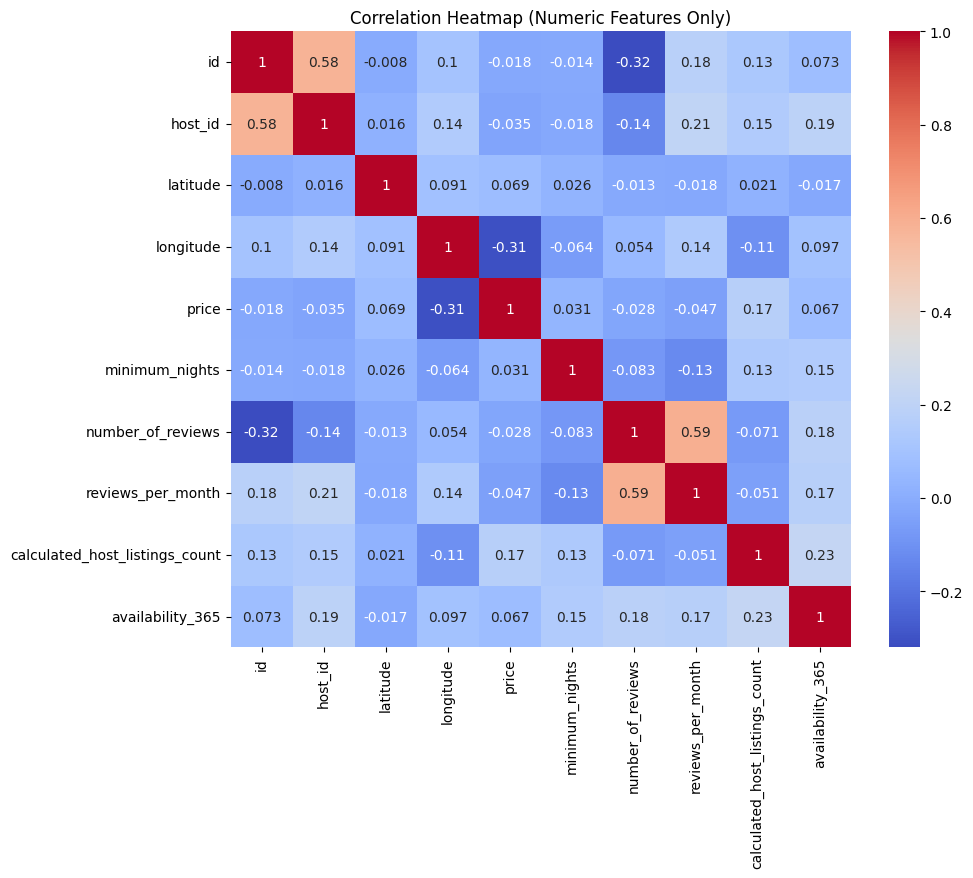

In [52]:
# Select only numeric columns
numeric_df = airbnb_data.select_dtypes(include=['int64', 'float64'])

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [100]:
corr = airbnb_data[['price','number_of_reviews','reviews_per_month','availability_365','minimum_nights']].corr(numeric_only=True)
display(corr)

,price,number_of_reviews,reviews_per_month,availability_365,minimum_nights
price,1.000000,-0.027680,-0.047383,0.066573,0.031434
number_of_reviews,-0.027680,1.000000,0.593843,0.183614,-0.082899
reviews_per_month,-0.047383,0.593843,1.000000,0.171457,-0.127805
availability_365,0.066573,0.183614,0.171457,1.000000,0.146457
minimum_nights,0.031434,-0.082899,-0.127805,0.146457,1.000000


*Geographic Analysis*

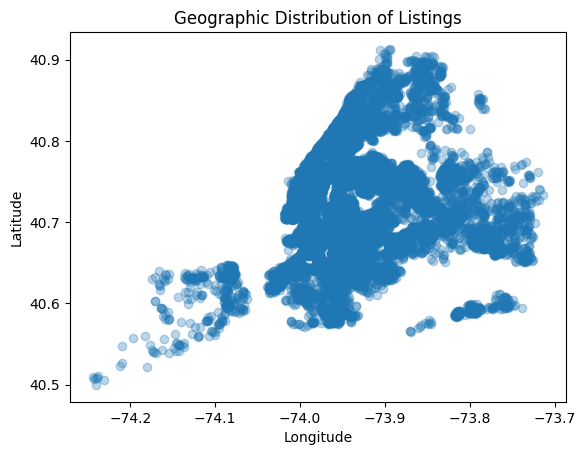

In [101]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(airbnb_data["longitude"], airbnb_data["latitude"], alpha=0.3)

plt.title("Geographic Distribution of Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

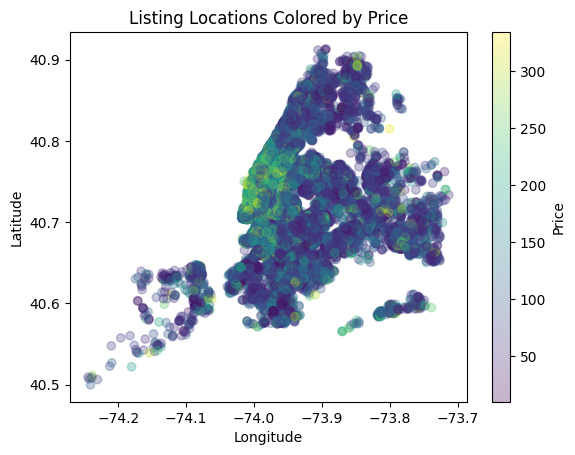

In [ ]:
#Color points by price
plt.figure()
plt.scatter(
    airbnb_data["longitude"],
    airbnb_data["latitude"],
    c=airbnb_data["price"],   
    alpha=0.3
)

plt.colorbar(label="Price")

plt.title("Listing Locations Colored by Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

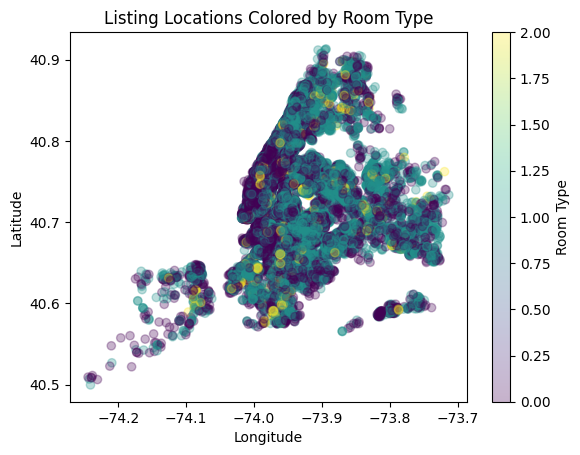

In [107]:
# Color points by room type
plt.figure()
plt.scatter(
    airbnb_data["longitude"],
    airbnb_data["latitude"],
    c=airbnb_data["room_type"].cat.codes,   # color by room type using category codes
    alpha=0.3
)

plt.colorbar(label="Room Type")
plt.title("Listing Locations Colored by Room Type")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [108]:
top_areas = (
    airbnb_data.groupby("neighbourhood")["id"]
    .count()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(top_areas.head(10))

          neighbourhood  listing_count
214        Williamsburg           3732
13   Bedford-Stuyvesant           3638
94               Harlem           2585
28             Bushwick           2438
202     Upper West Side           1788
95       Hell's Kitchen           1731
64         East Village           1714
201     Upper East Side           1670
51        Crown Heights           1519
127             Midtown           1144


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\710510392.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood")["id"]


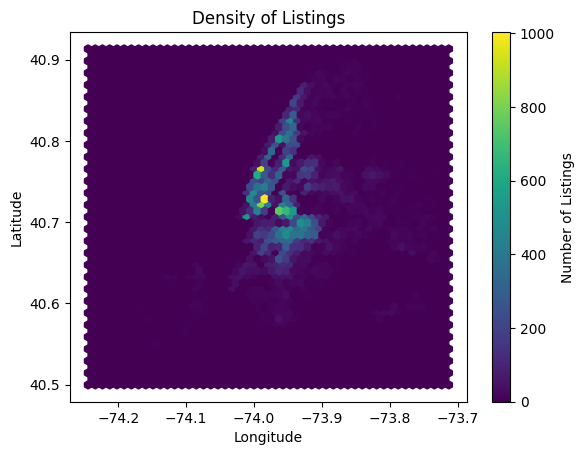

In [109]:
plt.figure()
plt.hexbin(
    airbnb_data["longitude"],
    airbnb_data["latitude"],
    gridsize=50
)

plt.colorbar(label="Number of Listings")

plt.title("Density of Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

*Data Visualization*

 Average Price by Neighbourhood Group

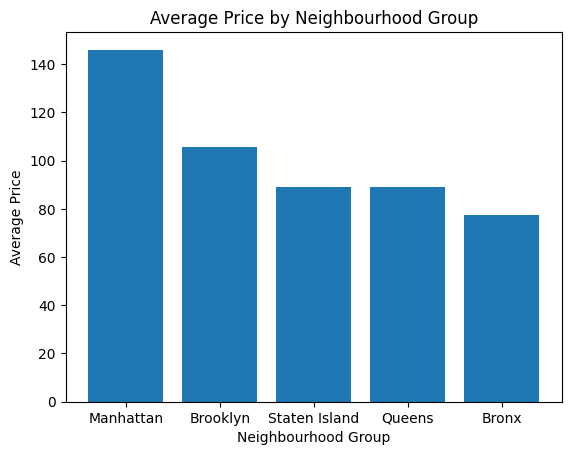

In [112]:
plt.figure()

plt.bar(
    avg_price_neighbourhood["neighbourhood_group"],
    avg_price_neighbourhood["avg_price"]
)

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")

plt.show()

Listings by Room Type


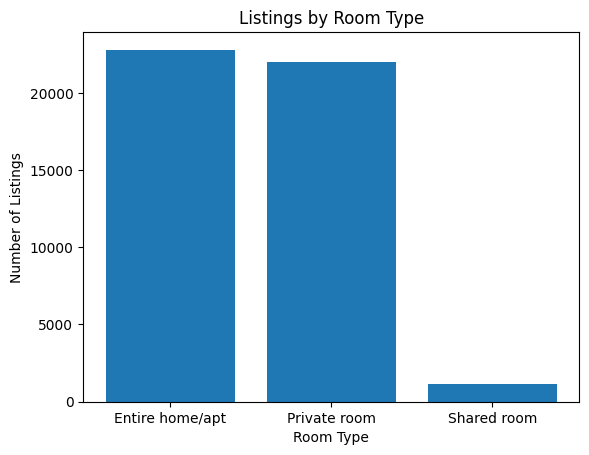

In [114]:
plt.figure()

plt.bar(
    listings_by_room_type["room_type"],
    listings_by_room_type["listing_count"]
)

plt.title("Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.show()

Price Distribution


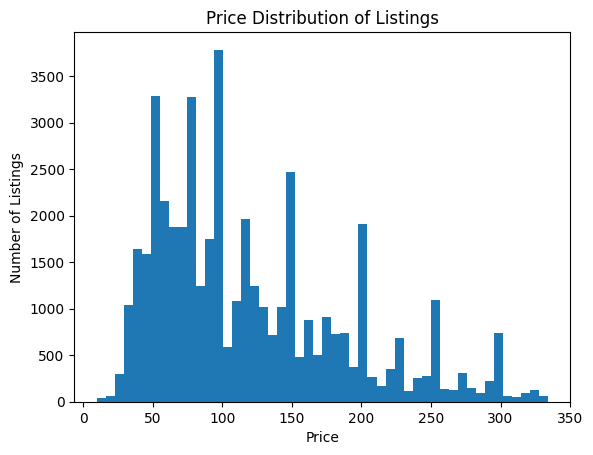

In [116]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(airbnb_data["price"], bins=50)

plt.title("Price Distribution of Listings")
plt.xlabel("Price")
plt.ylabel("Number of Listings")

plt.show()

Availability Distribution


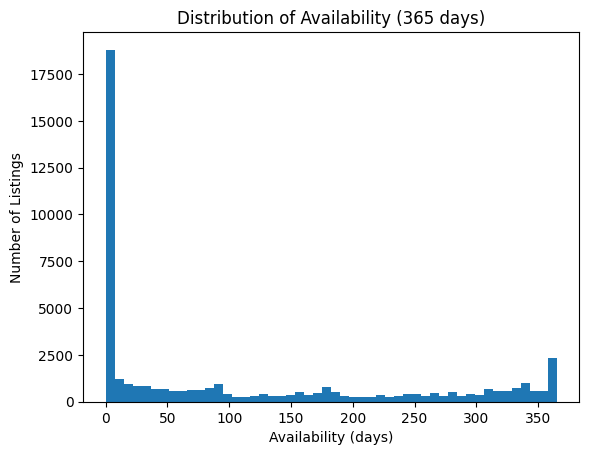

In [118]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(airbnb_data["availability_365"], bins=50)

plt.title("Distribution of Availability (365 days)")
plt.xlabel("Availability (days)")
plt.ylabel("Number of Listings")

plt.show()

Top Hosts


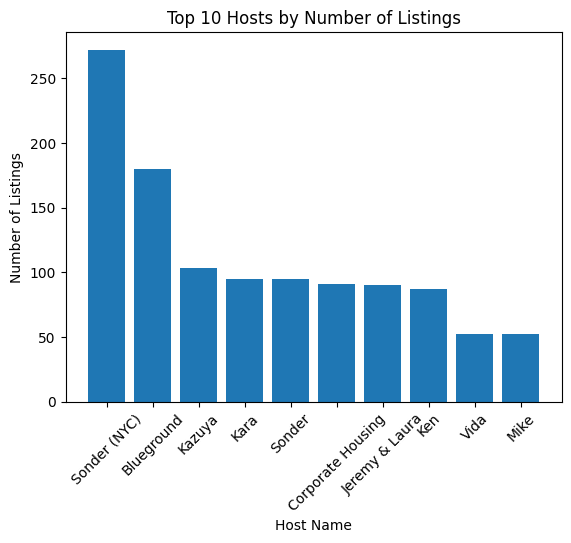

In [121]:
plt.figure()

plt.bar(
    top_hosts_listings ["host_name"],
    top_hosts_listings["listing_count"]
)

plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host Name")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)  # rotate names for readability

plt.show()

Correlation Heatmap


In [126]:
plt.figure()

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Add values inside cells
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Heatmap")



plt.show()

NameError: name 'corr_matrix' is not defined

<Figure size 640x480 with 0 Axes>